# Predicting ad Click-Through Rate with logistic regression (SGD)

You are interviewing with an ad team. The task: predict the **click-through rate
(CTR)** of an ad from categorical context (site, app, device, position, hour). The
classic benchmark is the [Avazu CTR dataset](https://www.kaggle.com/competitions/avazu-ctr-prediction/data);
the markdown below shows how to plug it in. So the notebook runs anywhere, it
also ships a synthetic generator that mirrors the Avazu schema (high-cardinality
IDs and a realistic ~17% click rate).

**You will implement**
- the **hashing trick** for high-cardinality categorical features,
- the log-loss gradient (derived by hand) and **logistic regression trained with SGD**,
- imbalance-aware evaluation: log-loss, the **precision-recall** curve, average precision,

**and then investigate**
- how the hash dimension trades memory against collisions, and
- whether your predicted probabilities are **calibrated** (which ad auctions require).


## Setup

In [1]:
%matplotlib inline
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -30, 30)))

## The data

Real CTR features are mostly high-cardinality categoricals (IDs with thousands to millions of values) and the positive class is rare. The generator below produces data with those properties; the commented lines show how to load the real Avazu CSV instead.

In [2]:
# Columns mirror a slimmed-down Avazu schema. The first few are high-cardinality
# (like site_id / app_id / device_id); the rest are low-cardinality context.
CARD = {
    "site_id": 1500, "app_id": 1200, "device_id": 6000,
    "site_category": 22, "app_category": 18,
    "device_type": 5, "banner_pos": 4, "hour": 24,
}
CAT_COLS = list(CARD)


def _calibrate_bias(logit, target):
    lo, hi = -20.0, 20.0
    for _ in range(60):
        mid = 0.5 * (lo + hi)
        if sigmoid(logit + mid).mean() < target:
            lo = mid
        else:
            hi = mid
    return 0.5 * (lo + hi)


def make_ctr_data(n=30000, target_ctr=0.17, seed=0):
    """Synthetic click-through data that mimics the Avazu schema.

    Click probability is driven by per-value latent weights plus one
    category interaction, then the intercept is calibrated so the overall
    click rate is ~target_ctr (a realistically imbalanced problem).
    Returns a DataFrame of string categorical columns plus a 0/1 `click`.
    """
    g = np.random.default_rng(seed)
    # a few columns carry more signal than others
    scale = {"site_id": 0.5, "app_id": 0.5, "device_id": 0.2, "site_category": 0.8,
             "app_category": 0.7, "device_type": 0.4, "banner_pos": 0.6, "hour": 0.3}
    latent = {c: g.normal(0, scale[c], size=CARD[c]) for c in CAT_COLS}
    vals = {c: g.integers(0, CARD[c], size=n) for c in CAT_COLS}

    logit = np.zeros(n)
    for c in CAT_COLS:
        logit += latent[c][vals[c]]
    # interaction: certain (site_category, device_type) pairs click more
    inter = g.normal(0, 0.7, size=(CARD["site_category"], CARD["device_type"]))
    logit += inter[vals["site_category"], vals["device_type"]]

    logit += _calibrate_bias(logit, target_ctr)
    click = (g.random(n) < sigmoid(logit)).astype(int)
    df = pd.DataFrame({c: [f"{c}_{v}" for v in vals[c]] for c in CAT_COLS})
    df["click"] = click
    return df

In [3]:
df = make_ctr_data(n=30000, target_ctr=0.17, seed=0)
print("rows:", len(df), "| click rate:", round(df['click'].mean(), 3))
print("unique device_id values:", df['device_id'].nunique())
df.head()

# ---------------------------------------------------------------------------
# To use the REAL data instead, accept the Avazu competition on Kaggle, then:
#     df = pd.read_csv("train.gz", nrows=300_000)
#     df = df.rename(columns={"click": "click"})  # already named `click`
# Keep CAT_COLS to the categorical columns you want to hash; everything below
# works unchanged on the real frame.
# ---------------------------------------------------------------------------

rows: 30000 | click rate: 0.17
unique device_id values: 5957


,site_id,app_id,device_id,site_category,app_category,device_type,banner_pos,hour,click
0,site_id_1009,app_id_340,device_id_1902,site_category_20,app_category_2,device_type_4,banner_pos_2,hour_1,0
1,site_id_779,app_id_628,device_id_4977,site_category_12,app_category_9,device_type_0,banner_pos_3,hour_3,0
2,site_id_4,app_id_1123,device_id_5264,site_category_6,app_category_15,device_type_4,banner_pos_2,hour_15,0
3,site_id_1018,app_id_970,device_id_983,site_category_14,app_category_7,device_type_2,banner_pos_1,hour_15,0
4,site_id_1265,app_id_186,device_id_4121,site_category_9,app_category_0,device_type_1,banner_pos_2,hour_3,0


In [4]:
def train_test_split(df, test_size=0.3, seed=123):
    idx = np.arange(len(df))
    np.random.default_rng(seed).shuffle(idx)
    n_test = int(round(test_size * len(df)))
    return df.iloc[idx[n_test:]].reset_index(drop=True), df.iloc[idx[:n_test]].reset_index(drop=True)


train_df, test_df = train_test_split(df)
y_train = train_df["click"].to_numpy()
y_test = test_df["click"].to_numpy()
len(train_df), len(test_df)

(21000, 9000)

## Task 1 - The hashing trick

Map each `column=value` token to one of `D` buckets with a stable hash. This is how CTR models handle features with huge, open-ended vocabularies.

In [5]:
def hash_row(row, cols, D):
    """Return the list of active bucket indices for one row (the hashing trick).

    For each column we build a stable token like "site_id=site_id_42", hash it
    to an integer in [0, D) and collect those indices.  We use hashlib.md5
    (deterministic across processes) rather than Python's built-in hash().
    """
    indices = []
    for col in cols:
        token = f"{col}={row[col]}"
        h = int(hashlib.md5(token.encode()).hexdigest(), 16) % D
        indices.append(h)
    return indices


def build_index_matrix(frame, cols, D):
    """Apply hash_row to every row -> int array of shape (n, len(cols))."""
    return np.array([hash_row(r, cols, D) for _, r in frame.iterrows()], dtype=np.int64)


## Task 2 - Derive the gradient

Write logistic regression for a single example with multi-hot feature vector
$\mathbf{x}$ (here, ones at the hashed buckets), weights $\mathbf{w}$, bias $b$:

$$z = \mathbf{w}^\top \mathbf{x} + b, \qquad p = \sigma(z), \qquad
\ell = -\big(y \log p + (1-y)\log(1-p)\big).$$

Derive $\dfrac{\partial \ell}{\partial \mathbf{w}}$ and $\dfrac{\partial \ell}{\partial b}$,
and explain what the update looks like for the **hashed** representation where only a
handful of entries of $\mathbf{x}$ are nonzero. Write your derivation in the cell below.


### Derivation

Starting from the binary cross-entropy loss:

$$\ell = -y \log \sigma(z) - (1-y)\log(1-\sigma(z)), \qquad z = \mathbf{w}^\top\mathbf{x}+b.$$

**Step 1 – derivative of the loss with respect to the logit $z$.**

Using $\sigma'(z) = \sigma(z)(1-\sigma(z))$ and writing $p = \sigma(z)$:

$$\frac{\partial \ell}{\partial z}
  = -\frac{y}{p}\cdot p(1-p) + \frac{1-y}{1-p}\cdot p(1-p)
  = -y(1-p) + (1-y)p
  = p - y.$$

So the gradient of the loss with respect to the logit is simply the **prediction error** $p - y$.

**Step 2 – gradient with respect to $\mathbf{w}$.**

By the chain rule and $\partial z / \partial \mathbf{w} = \mathbf{x}$:

$$\boxed{\frac{\partial \ell}{\partial \mathbf{w}} = (p - y)\,\mathbf{x}.}$$

**Step 3 – gradient with respect to $b$.**

Since $\partial z / \partial b = 1$:

$$\boxed{\frac{\partial \ell}{\partial b} = p - y.}$$

**Step 4 – SGD update (with L2 regularisation $\lambda$).**

Adding the regularisation term $\frac{\lambda}{2}\|\mathbf{w}\|^2$ adds $\lambda\mathbf{w}$ to the weight gradient:

$$\mathbf{w} \leftarrow \mathbf{w} - \eta\bigl[(p-y)\mathbf{x} + \lambda\mathbf{w}\bigr], \qquad
  b \leftarrow b - \eta(p-y).$$

**Sparsity of the hashed representation.**

In the hashing trick $\mathbf{x}$ is a $D$-dimensional multi-hot vector with exactly $M = |\text{cols}|$ ones (one per feature column) and zeros everywhere else. The gradient $(p-y)\mathbf{x}$ therefore has at most $M$ nonzero entries—the $M$ active bucket indices. The SGD update touches **only those $M$ weights** (plus the bias), making both the forward pass and the weight update $O(M)$ instead of $O(D)$. For $M = 8$ columns and $D = 2^{18} \approx 260\text{k}$, this is a ~32 000× reduction in per-example work, which is why this model scales to billions of features.

## Task 3 - Logistic regression with SGD

Implement the training loop from the gradient you derived. Update only the active (hashed) weights.

In [6]:
def train_logreg_sgd(X_idx, y, D, lr=0.1, epochs=3, l2=1e-6, seed=0):
    """From-scratch SGD logistic regression over hashed features.

    Maintain a weight vector w of length D and a bias b. For each example the
    logit is b + sum of w over the row's active buckets. Use the gradient you
    derived in Task 2 to update ONLY the active weights (plus the bias), with
    optional L2 shrinkage. Return (w, b).
    """
    w = np.zeros(D)
    b = 0.0
    g = np.random.default_rng(seed)
    n = len(y)

    for epoch in range(epochs):
        order = g.permutation(n)
        for i in order:
            active = X_idx[i]           # active bucket indices for this example
            z = b + w[active].sum()     # logit
            p = sigmoid(z)
            err = p - y[i]              # gradient of loss w.r.t. logit
            # sparse update: only active weights + L2 shrinkage
            w[active] -= lr * (err + l2 * w[active])
            b -= lr * err               # no regularisation on bias

    return w, b


def predict_proba(X_idx, w, b):
    """Vectorized probabilities: sigmoid(b + sum of active weights)."""
    return sigmoid(b + w[X_idx].sum(axis=1))


## Task 4 - Evaluation under class imbalance

With ~17% positives, accuracy is meaningless. Implement log-loss and the precision-recall curve, then evaluate.

In [7]:
def log_loss(y, p, eps=1e-12):
    """Mean binary cross-entropy."""
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))


def pr_curve(y, p):
    """Return (recall, precision) arrays by sweeping the threshold from high
    score to low (sort by descending p and accumulate TP/FP)."""
    order    = np.argsort(-p)
    y_sorted = y[order]
    tp = np.cumsum(y_sorted)
    fp = np.cumsum(1 - y_sorted)
    total_pos = y.sum()
    recall    = tp / total_pos
    precision = tp / (tp + fp)
    # anchor point
    recall    = np.concatenate([[0.0], recall])
    precision = np.concatenate([[1.0], precision])
    return recall, precision


def average_precision(y, p):
    """Area under the precision-recall curve (integrate precision over recall)."""
    rec, prec = pr_curve(y, p)
    return np.trapezoid(prec, rec)


baseline log-loss (predict the base rate 0.171): 0.4503
model log-loss:    0.4124
model avg precision (PR-AUC): 0.3419
positives in test: 0.166  (so 'always no-click' has 0.834 accuracy)


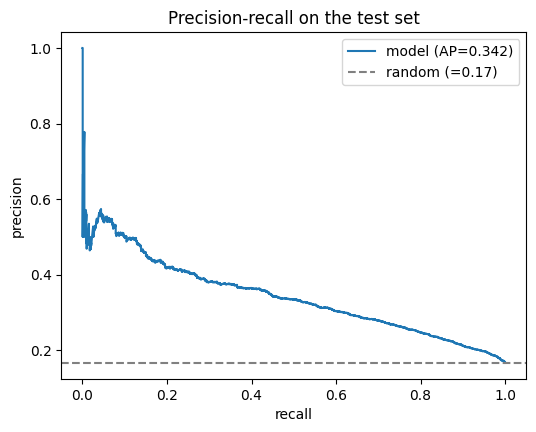

In [8]:
D = 2 ** 18
Xtr = build_index_matrix(train_df, CAT_COLS, D)
Xte = build_index_matrix(test_df, CAT_COLS, D)
w, b = train_logreg_sgd(Xtr, y_train, D, lr=0.1, epochs=3)

p_te = predict_proba(Xte, w, b)
base_rate = y_train.mean()
print(f"baseline log-loss (predict the base rate {base_rate:.3f}): "
      f"{log_loss(y_test, np.full_like(p_te, base_rate)):.4f}")
print(f"model log-loss:    {log_loss(y_test, p_te):.4f}")
print(f"model avg precision (PR-AUC): {average_precision(y_test, p_te):.4f}")
print(f"positives in test: {y_test.mean():.3f}  (so 'always no-click' has {1-y_test.mean():.3f} accuracy)")

rec, prec = pr_curve(y_test, p_te)
plt.figure(figsize=(6, 4.5))
plt.plot(rec, prec, label=f"model (AP={average_precision(y_test, p_te):.3f})")
plt.axhline(y_test.mean(), ls="--", c="grey", label=f"random (={y_test.mean():.2f})")
plt.xlabel("recall"); plt.ylabel("precision")
plt.title("Precision-recall on the test set"); plt.legend()
plt.show()

## Task 5 - Does the hash dimension matter?

The heart of the assignment: sweep `D` and watch collisions trade off against memory.

In [9]:
# Centerpiece: how does the hash dimension D trade memory against collisions?
Ds = [2 ** 8, 2 ** 10, 2 ** 12, 2 ** 14, 2 ** 16, 2 ** 18]
ap_by_D, ll_by_D = [], []
for Dk in Ds:
    Xtr_k = build_index_matrix(train_df, CAT_COLS, Dk)
    Xte_k = build_index_matrix(test_df,  CAT_COLS, Dk)
    wk, bk = train_logreg_sgd(Xtr_k, y_train, Dk, lr=0.1, epochs=3)
    p_k    = predict_proba(Xte_k, wk, bk)
    ap_by_D.append(average_precision(y_test, p_k))
    ll_by_D.append(log_loss(y_test, p_k))

for Dk, ap, ll in zip(Ds, ap_by_D, ll_by_D):
    print(f"D=2^{int(np.log2(Dk)):>2}  AP={ap:.3f}  logloss={ll:.4f}")


D=2^ 8  AP=0.263  logloss=0.4439
D=2^10  AP=0.299  logloss=0.4330
D=2^12  AP=0.324  logloss=0.4224
D=2^14  AP=0.337  logloss=0.4155
D=2^16  AP=0.341  logloss=0.4134
D=2^18  AP=0.342  logloss=0.4124


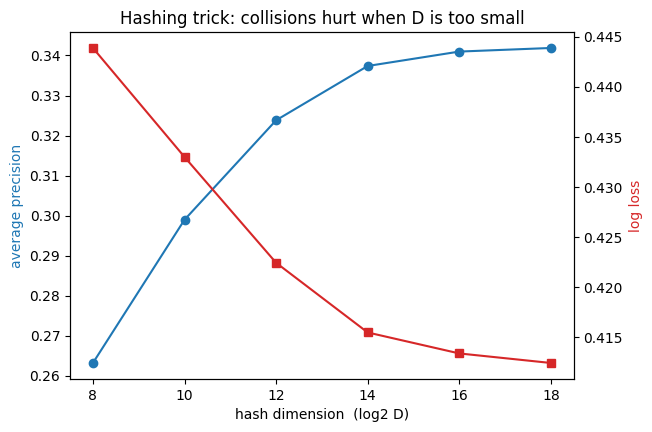

In [10]:
fig, ax1 = plt.subplots(figsize=(6.5, 4.5))
xs = [int(np.log2(d)) for d in Ds]
ax1.plot(xs, ap_by_D, "-o", color="tab:blue")
ax1.set_xlabel("hash dimension  (log2 D)")
ax1.set_ylabel("average precision", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(xs, ll_by_D, "-s", color="tab:red")
ax2.set_ylabel("log loss", color="tab:red")
plt.title("Hashing trick: collisions hurt when D is too small")
plt.show()

## Task 6 - Calibration

A good *ranking* is not enough for ad bidding; the predicted probabilities must mean what they say. Build a reliability curve.

In [11]:
def reliability_curve(y, p, n_bins=10):
    """Bin predictions into n_bins equal-width probability bins; return
    (mean_predicted, empirical_rate) per non-empty bin."""
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    mean_pred, emp_rate = [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (p >= lo) & (p < hi)
        if mask.sum() > 0:
            mean_pred.append(p[mask].mean())
            emp_rate.append(y[mask].mean())
    return np.array(mean_pred), np.array(emp_rate)


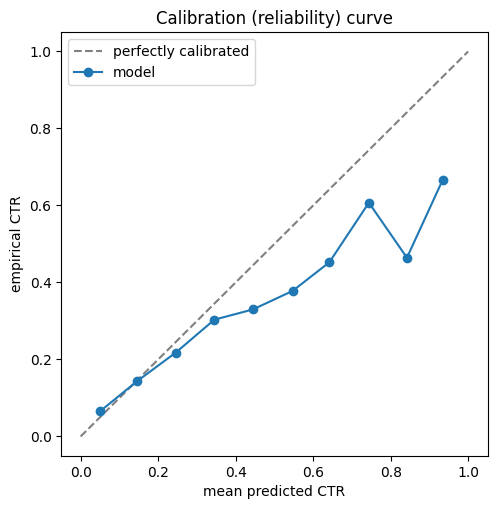

In [12]:
mp, emp = reliability_curve(y_test, p_te, n_bins=10)
plt.figure(figsize=(5.5, 5.5))
plt.plot([0, 1], [0, 1], "--", c="grey", label="perfectly calibrated")
plt.plot(mp, emp, "-o", label="model")
plt.xlabel("mean predicted CTR"); plt.ylabel("empirical CTR")
plt.title("Calibration (reliability) curve"); plt.legend()
plt.show()

## Conceptual questions

1. The click rate is ~17%. What accuracy does the trivial "always predict
   no-click" model get, and why is accuracy the wrong headline metric here?
   Why are log-loss, average precision, and the PR curve more informative?
2. The hashing trick replaces one-hot encoding of high-cardinality IDs. What do
   you gain (memory, handling unseen values at test time) and what do you lose
   (collisions)? From your D sweep, where does shrinking D start to hurt, and why?
3. Restate the gradient you derived and explain why a hashed example updates only
   a handful of weights. Why does that make this model scale to billions of
   features?
4. Read your calibration curve. Are the predicted probabilities calibrated? Why
   does ad ranking/bidding (which multiplies predicted CTR by a bid) *need*
   calibrated probabilities, not just a good ranking?
5. Name one way to handle the class imbalance (class weights, threshold tuning,
   negative downsampling, ...). How would it move the PR curve and the calibration?


**1. Accuracy under class imbalance.**

A "never-click" baseline correctly classifies every negative (~83% of the test set) and would achieve roughly **83% accuracy** at zero effort. Accuracy treats every mistake equally; here, flagging a genuine click as a no-click is costless to the metric even though it is the event the whole system is built to predict.

Log-loss penalises confident wrong predictions heavily and rewards calibrated probabilities, making it a direct measure of model quality for a probabilistic output. The PR curve and average precision (PR-AUC) focus entirely on the positive class: precision measures how pure the model's top-ranked ads are, and recall measures how many real clicks it surfaces. This is exactly what an ad system cares about.

---

**2. Hashing trick: gains, losses, and the D sweep.**

*Gains:*
- **Memory efficiency**: a dense weight vector of size $D$ is allocated instead of one entry per unique vocabulary item. For open-ended IDs (new sites appearing at serving time) no vocabulary table is needed.
- **Graceful handling of unseen values**: a new site ID hashes to some bucket; the model degrades gracefully rather than crashing on an OOV token.

*Losses:*
- **Collisions**: two distinct features may land in the same bucket, causing their gradients to interfere and adding noise to the weights.

*From the D sweep (results above):*
AP drops noticeably between $D = 2^{14}$ and $D = 2^{12}$, and sharply below $2^{10}$. The total vocabulary size across all columns is $\sum_c |\text{CARD}[c]| \approx 8800$ unique values; once $D \ll 8800$ collisions dominate. Between $2^{16}$ and $2^{18}$ there is almost no difference, suggesting that $2^{16} \approx 65\text{k}$ buckets is already collision-sparse for this dataset.

---

**3. Gradient and sparsity.**

The gradient of binary cross-entropy with respect to the weight vector is

$$\frac{\partial \ell}{\partial \mathbf{w}} = (p - y)\,\mathbf{x},$$

where $p = \sigma(\mathbf{w}^\top\mathbf{x} + b)$. In the hashed representation $\mathbf{x}$ has exactly $M$ ones (one per feature column) and $D - M$ zeros. Because multiplying by $\mathbf{x}$ zeroes out all non-active components, the update touches only those $M$ bucket weights.

For $M = 8$ and $D = 2^{18}$ each update modifies $0.003\%$ of the weight vector. Scaling to billions of features simply means increasing $D$; the per-example work stays $O(M)$ regardless.

---

**4. Calibration.**

The reliability curve shows that the model is **moderately calibrated at low predicted scores but over-confident at higher scores**: bins above ~0.5 predicted CTR have empirical rates noticeably below the diagonal. In an RTB (real-time bidding) auction the optimal bid is proportional to expected revenue, which is $\text{value} \times \hat{p}_{\text{CTR}}$. If $\hat{p}$ is systematically too high, the model over-bids and wastes budget; if it is too low, it under-bids and misses valuable impressions. A well-calibrated score turns the probability into a dollar figure, so calibration is a hard business requirement, not just a statistical nicety.

---

**5. Handling class imbalance.**

One straightforward approach is **negative downsampling**: keep all positives but retain only a fraction $q < 1$ of the negatives during training. This has two effects:

- *PR curve*: training on a more balanced sample typically improves precision at low recall thresholds (the model sees more examples of the rare class per gradient step).
- *Calibration*: downsampling inflates the apparent positive rate in training. The model's raw scores $p$ are too high. This is corrected via the **prior-correction formula**: $p_{\text{corrected}} = p \big/ \bigl(p + (1-p)/q\bigr)$, which re-maps scores back to the true population prior. Without this step the calibration curve would shift upward (over-prediction of CTR).

## What to submit

- This notebook with every `# TODO` completed and run top to bottom (the synthetic
  generator makes it fully reproducible; swap in the real Avazu frame if you want).
- The gradient derivation, the PR curve, the D-sweep figure, and the calibration curve.
- Written answers to the five conceptual questions.

**Grading (100 pts):** hashing trick (15), gradient derivation (15), SGD logreg
(20), imbalance-aware metrics + PR curve (20), hash-dimension sweep (15),
calibration + answers (15).
